In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

N_ITERS = 1
T_OFFSET = 70
T_OFFSET_IFSTAT = 80
T_END = 100

ROW_LABELS = ["C-S", "Trickle", "Ours"]

DATA_A_LABEL = "bandwidth usage (Mbps)"
DATA_B_LABEL = "peer discovery rate (%)"
AXIS_FONT_SIZE = 11
VALUE_FONT_SIZE = 8
GROUP_A_COLOR: str = "#00008b"
GROUP_B_COLOR: str = "#06DF00"

# Spacing configuration constants
PLOT_HEIGHT_PER_GROUP = 1        # Height in inches for each group of 3 subplots
PLOT_WIDTH = 5                      # Width in inches
HSPACE_WITHIN_GROUP = -0.01          # Vertical space between plots within a group
HSPACE_BETWEEN_GROUPS = 1.1       # Vertical space between different groups
MARGIN_LEFT = 0.0                  # Left margin (controls distance to left y-axis labels)
MARGIN_RIGHT = 0.92                 # Right margin (controls distance to right y-axis labels)
MARGIN_TOP = 0.98                   # Top margin
MARGIN_BOTTOM = 0.04                # Bottom margin (controls distance to x-axis labels)
GROUP_LABEL_Y_OFFSET = 1.15         # Vertical offset for group label text above each group
ROW_LABEL_X_OFFSET = -0.1           # Horizontal offset for row labels (C-S, Trickle, Ours)

def plot_3_dual_axis(data: list[tuple[list[tuple[list[float], list[float]]], list[tuple[list[float], list[float]]]]]):
    if len(data) != 3:
        raise ValueError(f"Expected 3 data entries, got {len(data)}.")

    fig, axes = plt.subplots(3, 1, figsize=(PLOT_WIDTH, 4))
    fig.subplots_adjust(left=MARGIN_LEFT, right=MARGIN_RIGHT, top=0.95, bottom=0.08,
                        hspace=HSPACE_WITHIN_GROUP, wspace=0.15)

    axes_left  = []
    axes_right = []

    for idx, ax_left in enumerate(axes.flat):
        row = idx  # Since we have 3 rows, 1 column
        data_a, data_b = data[idx]

        # --- Group A: solid lines, left y-axis ---
        for x, y in data_a:
            ax_left.plot(x, y, color=GROUP_A_COLOR, linewidth=0.5,
                         linestyle="-", alpha=0.03)

        # --- Group B: dashed lines, right y-axis ---
        ax_right = ax_left.twinx()
        for x, y in data_b:
            ax_right.plot(x, y, color=GROUP_B_COLOR, linewidth=2,
                          linestyle="--", alpha=1)

        ax_left.set_ylim(0, 4)
        ax_right.set_ylim(0, 105)
        ax_left.set_xlim(0, T_END)

        ax_left.tick_params(axis="y", labelcolor=GROUP_A_COLOR, labelsize=VALUE_FONT_SIZE)
        ax_right.tick_params(axis="y", labelcolor=GROUP_B_COLOR, labelsize=VALUE_FONT_SIZE)
        ax_left.tick_params(axis="x", labelsize=VALUE_FONT_SIZE)

        # x-axis labels only on bottom row
        if row != 2:
            ax_left.tick_params(axis="x", labelbottom=False)

        #ax_left.set_ylabel("")
        #ax_right.set_ylabel("")

        ax_left.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
        ax_left.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_right.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_left.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        axes_left.append(ax_left)
        axes_right.append(ax_right)

    # # --- Single legend for both groups ---
    legend_handles = [
        plt.Line2D([0], [0], color=GROUP_A_COLOR, linewidth=2, linestyle="-",  label=DATA_A_LABEL),
        plt.Line2D([0], [0], color=GROUP_B_COLOR, linewidth=2, linestyle="--", label=DATA_B_LABEL),
    ]
    fig.legend(handles=legend_handles, loc="upper right", fontsize=VALUE_FONT_SIZE,
               framealpha=0.8, edgecolor="none", bbox_to_anchor=(1, 1.07))

    # --- Row labels to the left of each row ---
    for row, label in enumerate(ROW_LABELS):
        axes[row].annotate(
            str(label),
            xy=(0, 0.5), xycoords="axes fraction",
            xytext=(ROW_LABEL_X_OFFSET, 0.5), textcoords="axes fraction",
            fontsize=AXIS_FONT_SIZE, 
            family='serif',
            ha="center", va="center",
            rotation=90,
            annotation_clip=False,
        )

    return fig

def plot_multi_groups_dual_axis(data_groups: list[tuple[str, list[tuple[list[tuple[list[float], list[float]]], list[tuple[list[float], list[float]]]]]]], 
                                   ylim_left: list[tuple[float, float]] = None,
                                   ylim_right: list[tuple[float, float]] = None):
    """
    Plot multiple groups of 3 subplots with text separators between groups.
    
    Args:
        data_groups: List of tuples (group_label, data) where data is the same format as plot_3_dual_axis
        ylim_left: Optional list of (min, max) tuples for left y-axis range for each group. 
                   If None, defaults to (0, 4) for all groups.
        ylim_right: Optional list of (min, max) tuples for right y-axis range for each group.
                    If None, defaults to (0, 105) for all groups.
    """
    num_groups = len(data_groups)
    total_rows = num_groups * 3  # 3 plots per group
    
    # Set default y-axis limits if not provided
    if ylim_left is None:
        ylim_left = [(0, 4)] * num_groups
    if ylim_right is None:
        ylim_right = [(0, 105)] * num_groups
    
    if len(ylim_left) != num_groups:
        raise ValueError(f"ylim_left must have {num_groups} entries, got {len(ylim_left)}")
    if len(ylim_right) != num_groups:
        raise ValueError(f"ylim_right must have {num_groups} entries, got {len(ylim_right)}")
    
    fig, axes = plt.subplots(total_rows, 1, figsize=(PLOT_WIDTH, PLOT_HEIGHT_PER_GROUP * num_groups))
    
    # Initial adjustment with uniform spacing
    fig.subplots_adjust(left=MARGIN_LEFT, right=MARGIN_RIGHT, top=MARGIN_TOP, bottom=MARGIN_BOTTOM,
                        hspace=HSPACE_WITHIN_GROUP, wspace=0.15)

    axes_left  = []
    axes_right = []
    
    # Calculate custom spacing: tight within groups, wider between groups
    # We'll manually adjust positions after plotting
    custom_positions = []
    for group_idx in range(num_groups):
        for subplot_idx in range(3):
            custom_positions.append((group_idx, subplot_idx))

    for group_idx, (group_label, data) in enumerate(data_groups):
        if len(data) != 3:
            raise ValueError(f"Expected 3 data entries per group, got {len(data)} for group '{group_label}'.")
        
        # Calculate the starting row for this group
        start_row = group_idx * 3
        
        for idx in range(3):
            ax_idx = start_row + idx
            ax_left = axes[ax_idx]
            data_a, data_b = data[idx]

            # --- Group A: solid lines, left y-axis ---
            for x, y in data_a:
                ax_left.plot(x, y, color=GROUP_A_COLOR, linewidth=0.5,
                             linestyle="-", alpha=0.03)

            # --- Group B: dashed lines, right y-axis ---
            ax_right = ax_left.twinx()
            for x, y in data_b:
                ax_right.plot(x, y, color=GROUP_B_COLOR, linewidth=2,
                              linestyle="--", alpha=1)

            ax_left.set_ylim(ylim_left[group_idx])
            ax_right.set_ylim(ylim_right[group_idx])
            ax_left.set_xlim(0, T_END)

            ax_left.tick_params(axis="y", labelcolor=GROUP_A_COLOR, labelsize=VALUE_FONT_SIZE)
            ax_right.tick_params(axis="y", labelcolor=GROUP_B_COLOR, labelsize=VALUE_FONT_SIZE)
            ax_left.tick_params(axis="x", labelsize=VALUE_FONT_SIZE)

            # x-axis labels only on bottom row of each group
            if idx != 2:
                ax_left.tick_params(axis="x", labelbottom=False)

            ax_left.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
            ax_left.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
            ax_right.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
            ax_left.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
            axes_left.append(ax_left)
            axes_right.append(ax_right)
            
            # Add row labels (C-S, Trickle, Ours)
            axes[ax_idx].annotate(
                str(ROW_LABELS[idx]),
                xy=(0, 0.5), xycoords="axes fraction",
                xytext=(ROW_LABEL_X_OFFSET, 0.5), textcoords="axes fraction",
                fontsize=AXIS_FONT_SIZE, 
                family='serif',
                ha="center", va="center",
                rotation=90,
                annotation_clip=False,
            )
        
        # Add group label text above the first plot of each group
        axes[start_row].annotate(
            group_label,
            xy=(0.5, 1.0), xycoords="axes fraction",
            xytext=(0.5, GROUP_LABEL_Y_OFFSET), textcoords="axes fraction",
            fontsize=AXIS_FONT_SIZE + 1,
            fontweight='bold',
            ha="center", va="bottom",
            annotation_clip=False,
        )

    # Manually adjust subplot positions for custom spacing within/between groups
    total_height = MARGIN_TOP - MARGIN_BOTTOM
    # Calculate heights: space for plots + space for spacing
    num_within_spaces = num_groups * 2  # 2 spaces within each group (between 3 plots)
    num_between_spaces = num_groups - 1  # spaces between groups
    
    total_spacing = (num_within_spaces * HSPACE_WITHIN_GROUP + 
                     num_between_spaces * HSPACE_BETWEEN_GROUPS)
    plot_height = (total_height - total_spacing) / total_rows
    
    current_bottom = MARGIN_BOTTOM
    for group_idx in range(num_groups - 1, -1, -1):  # Bottom to top
        for subplot_idx in range(2, -1, -1):  # Bottom subplot first
            ax_idx = group_idx * 3 + subplot_idx
            pos = axes[ax_idx].get_position()
            new_pos = [pos.x0, current_bottom, pos.width, plot_height]
            axes[ax_idx].set_position(new_pos)
            
            # Add spacing
            if subplot_idx > 0:  # Not the top subplot of the group
                current_bottom += plot_height + HSPACE_WITHIN_GROUP
            else:  # Top subplot of the group
                current_bottom += plot_height
                if group_idx > 0:  # Not the last group
                    current_bottom += HSPACE_BETWEEN_GROUPS
    
    # --- Single legend for both groups ---
    legend_handles = [
        plt.Line2D([0], [0], color=GROUP_A_COLOR, linewidth=2, linestyle="-",  label=DATA_A_LABEL),
        plt.Line2D([0], [0], color=GROUP_B_COLOR, linewidth=2, linestyle="--", label=DATA_B_LABEL),
    ]
    fig.legend(handles=legend_handles, loc="upper right", fontsize=VALUE_FONT_SIZE,
               framealpha=0.8, edgecolor="none", bbox_to_anchor=(0.99, 0.995))

    return fig

In [22]:
def read_data(target: str, n_peers: int) -> tuple[list[tuple[list[float], list[float]]], list[tuple[list[float], list[float]]]]:
    n_data = []
    for i in range(N_ITERS):
        for h in range(n_peers):
            time_points = []
            netusages = []
            with open(f'../continuous/{target}/{n_peers}/{i}/ifstat_h{h+1}.log', 'r') as f:
                # Skip first two title lines
                next(f, None)
                next(f, None)

                for line_no, line in enumerate(f):
                    execution_time = line_no / 10 - T_OFFSET_IFSTAT
                    netusage = sum([float(v) for v in line.strip().split()])/1000
                    
                    # skip before continuous
                    if execution_time < -1.0:
                        continue
                    
                    time_points.append(execution_time)
                    netusages.append(netusage)
            n_data.append((time_points[:(1-10)], np.convolve(netusages, np.ones(10)/10, mode='valid')))
    
    r_data = []
    for i in range(N_ITERS):
        with open(f'../continuous/{target}/{n_peers}/r_{i}.txt', 'r') as f:
            time_init = 0
            time_points = []
            reachabilities = []
            
            for line in f:
                parts = line.strip().split()
                if parts[1] == 'N/A':
                    continue

                time = int(parts[0])
                if time_init == 0:
                    time_init = time
                execution_time = (time - time_init) / 1000 - T_OFFSET
                reachability = float(parts[1])
                    
                # skip before continuous
                if execution_time < -1.0:
                    continue
                    
                # time interpolation
                if len(time_points) > 0:
                    time_points.append(execution_time)
                    reachabilities.append(reachabilities[-1])
                
                time_points.append(execution_time)
                reachabilities.append(reachability * 100)

            if time_points[-1] < T_END:
                time_points.append(float(T_END))
                reachabilities.append(reachabilities[-1])

            r_data.append((time_points, reachabilities))
    
    return (n_data, r_data)

In [23]:
def read_data_all(n_peers) -> list[tuple[list[tuple[list[float], list[float]]], list[tuple[list[float], list[float]]]]]:
    return [read_data(target, n_peers) for target in ['client-server', 'dev-eval-trickle', 'dev-v2']]

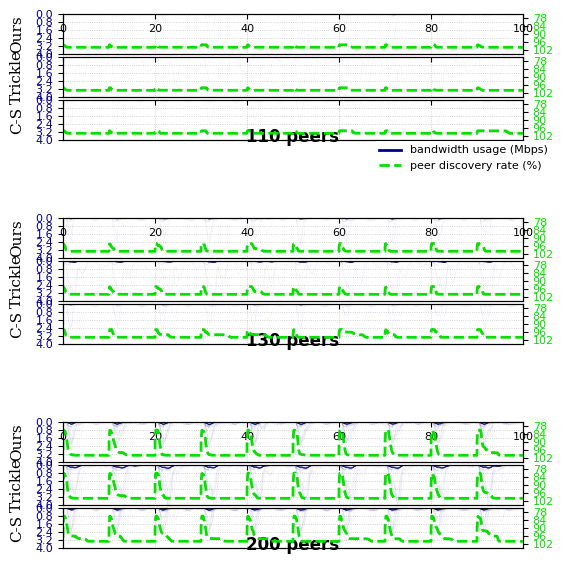

In [24]:
# Create data groups with labels
data_groups = [
    ("110 peers", read_data_all(110)),
    ("130 peers", read_data_all(130)),
    ("200 peers", read_data_all(200)),
]

# Optional: Customize y-axis ranges for each group
# Format: [(min, max), (min, max), (min, max)] for each group
ylim_left_custom = [(0, 4), (0, 4), (0, 4)]     # Left y-axis (bandwidth)
ylim_right_custom = [(75, 105), (75, 105), (75, 105)]  # Right y-axis (peer discovery rate)

fig = plot_multi_groups_dual_axis(data_groups, ylim_left=ylim_left_custom, ylim_right=ylim_right_custom)
fig.savefig("dual_axis_3.png", dpi=300, bbox_inches="tight")